# CommonVoice human word recognition pilot task results

In [7]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Import human data

In [45]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/commonvoice_word_recognition/data/')
!ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("*.json"))

# import vocab dict for matching audio & responses 
class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_word_int_label_dict.pkl", "rb" )) 
ix_to_word_map = {v:k for k,v in class_map.items()}

index.html			    subj_5dc0d311e5dc4108137d7c10.json
subj_57a5c633275be6000135b61c.json  subj_5ea9a41b87b4150bf9634637.json
subj_583dd5196bbe2c00017a16d1.json  subj_5f4412624052727181839e3a.json
subj_5c2477b010677f0001db2661.json  subj_6043cf7ccf14fb3f2610bdcf.json
subj_5c8b065abd96ce0001947d1b.json  subj_611ecf1c48f5f4a9004cecbc.json
subj_5cc4d09b050b2e00154baa4e.json  subj_6344bee5162a79b88400ec7c.json
subj_5d20e5aea3262d0017af1588.json  subj_63d3fc22b04877ba80e658cd.json
subj_5d7d74cf1822680001b2447e.json


In [11]:
eg_part_data = json.load(open(human_fnames[0], 'r'))
eg_df = pd.DataFrame.from_records(eg_part_data)

In [146]:
## Get all subject data into one df for analysis
def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df


dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)
expmnt_trial_str = "dictionary-text"

Unterminated string starting at: line 1 column 96611 (char 96610)
/mindhive/mcdermott/www/imgriff/msjspsych/commonvoice_word_recognition/data/subj_6344bee5162a79b88400ec7c.json


In [147]:
results_df

,success,timeout,failed_images,failed_audio,failed_video,trial_type,trial_index,time_elapsed,internal_node_id,jspsych_id,...,rt,response,question_order,stimulus,stim_type,hc_answer,hc_correct,response_str,control_trial,correct_response
0,True,False,[],[],[],preload,0,324,0.0-0.0,pmhcvtpab6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,instructions,1,2877,0.0-1.0,pmhcvtpab6,...,2553.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,2,8310,0.0-3.0,pmhcvtpab6,...,5311.0,"{'country': 'UK', 'language': 'English', 'gend...","[0, 1, 2]",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,3,22085,0.0-4.0,pmhcvtpab6,...,13772.0,"{'headphones': 'Over-the-ear headphones', 'con...","[0, 1, 2, 3, 4]",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,survey-text,4,32772,0.0-5.0,pmhcvtpab6,...,10685.0,"{'age': '27', 'worker_id': '57a5c633275be60001...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638,NaN,NaN,NaN,NaN,NaN,dictionary-text,638,1945137,0.0-12.0-1.0-1.310,ugk475x5e0,...,1241.0,books,NaN,stim/v01_cv_eval/condition02/401_000.wav,NaN,NaN,NaN,books,0.0,books
639,NaN,NaN,NaN,NaN,NaN,audio-keyboard-response,639,1947981,0.0-12.0-1.0-0.311,ugk475x5e0,...,NaN,None,NaN,stim/v01_cv_eval/condition01/207_000.wav,NaN,NaN,NaN,NaN,NaN,NaN
640,NaN,NaN,NaN,NaN,NaN,dictionary-text,640,1949233,0.0-12.0-1.0-1.311,ugk475x5e0,...,1240.0,party,NaN,stim/v01_cv_eval/condition01/207_000.wav,NaN,NaN,NaN,party,0.0,party
641,NaN,NaN,NaN,NaN,NaN,survey-text,641,1961093,0.0-12.0-2.0,ugk475x5e0,...,11838.0,{'Q0': 'That was a lot harder than I expected....,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [148]:
## Map wav str to stim_type using condition dict
import re

exp_dir = Path('/om2/user/imgriff/projects/Auditory-Attention/behavioral_experiments/commonvoice_word_rec/')
with open(exp_dir/'pilot_condiition_dict.pkl', 'rb') as handle:
    stim_cond_map = pickle.load(handle)

print(stim_cond_map)

def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            snr, condition = stim_cond_map[cond_str]
            return snr, condition 
    return None, None


results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

{'condition00': (0, 'clean'), 'condition01': (0, 'stationary_noise'), 'condition02': (0, 'natural_scene')}


In [305]:
model_stim = pd.read_pickle(exp_dir / 'pilot_stimuli_to_condition_manifest.pdpkl')

In [311]:
model_results = pd.read_csv("attn_cue_models/cv_word_rec_pilot/CommonVoice_attn_task_clean_pilot_cv_clean_word_rec_baseline/version_2/metrics.csv")

In [312]:
model_results

,Losses/test_loss,ACC/test_acc_step,step,ACC/test_acc_epoch,epoch
0,1.267998,0.781250,0,NaN,NaN
1,1.383311,0.718750,1,NaN,NaN
2,1.697943,0.687500,2,NaN,NaN
3,1.527825,0.687500,3,NaN,NaN
4,2.683499,0.625000,4,NaN,NaN
5,2.351934,0.593750,5,NaN,NaN
6,1.720407,0.687500,6,NaN,NaN
7,1.815536,0.625000,7,NaN,NaN
8,2.562236,0.593750,8,NaN,NaN
9,2.666526,0.468750,9,NaN,NaN


In [149]:
results_df

,success,timeout,failed_images,failed_audio,failed_video,trial_type,trial_index,time_elapsed,internal_node_id,jspsych_id,...,question_order,stimulus,stim_type,hc_answer,hc_correct,response_str,control_trial,correct_response,snr,condition
0,True,False,[],[],[],preload,0,324,0.0-0.0,pmhcvtpab6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,NaN,NaN,NaN,NaN,NaN,instructions,1,2877,0.0-1.0,pmhcvtpab6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,2,8310,0.0-3.0,pmhcvtpab6,...,"[0, 1, 2]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,3,22085,0.0-4.0,pmhcvtpab6,...,"[0, 1, 2, 3, 4]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,NaN,NaN,NaN,NaN,NaN,survey-text,4,32772,0.0-5.0,pmhcvtpab6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638,NaN,NaN,NaN,NaN,NaN,dictionary-text,638,1945137,0.0-12.0-1.0-1.310,ugk475x5e0,...,NaN,stim/v01_cv_eval/condition02/401_000.wav,NaN,NaN,NaN,books,0.0,books,0.0,natural_scene
639,NaN,NaN,NaN,NaN,NaN,audio-keyboard-response,639,1947981,0.0-12.0-1.0-0.311,ugk475x5e0,...,NaN,stim/v01_cv_eval/condition01/207_000.wav,NaN,NaN,NaN,NaN,NaN,NaN,0.0,stationary_noise
640,NaN,NaN,NaN,NaN,NaN,dictionary-text,640,1949233,0.0-12.0-1.0-1.311,ugk475x5e0,...,NaN,stim/v01_cv_eval/condition01/207_000.wav,NaN,NaN,NaN,party,0.0,party,0.0,stationary_noise
641,NaN,NaN,NaN,NaN,NaN,survey-text,641,1961093,0.0-12.0-2.0,ugk475x5e0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [162]:
results_df['accuracy'] = (results_df['response_str'] == results_df['correct_response']).astype('int')
catch_trial_particiapnt_performance = results_df[results_df.control_trial == 1].groupby('jspsych_id').accuracy.mean()
catch_trial_particiapnt_performance

jspsych_id
6pfy0m3tfb    1.000000
7b1kgl4l0g    0.833333
9277lbgwds    1.000000
bf68vv4jb8    0.750000
cpnbblrgma    0.916667
pmhcvtpab6    0.833333
se0a1dosp2    0.750000
ugk475x5e0    0.916667
vgbrx2o3mb    1.000000
Name: accuracy, dtype: float64

In [273]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance > 9/12].index
print("N good participants ", len(good_participants))

# good_results = results_df[results_df.jspsych_id.isin(good_participants)]

N total participants  9
N good participants  7


In [278]:
# get trial data excluding catch trials 
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]


part_summary_df = (analysis_df.groupby(["snr", 'jspsych_id', "condition"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())



In [279]:
part_summary_df

,snr,jspsych_id,condition,mean
0,0.0,6pfy0m3tfb,clean,0.362500
1,0.0,6pfy0m3tfb,natural_scene,0.240506
2,0.0,6pfy0m3tfb,stationary_noise,0.192308
3,0.0,7b1kgl4l0g,clean,0.320000
4,0.0,7b1kgl4l0g,natural_scene,0.160000
5,0.0,7b1kgl4l0g,stationary_noise,0.090000
6,0.0,9277lbgwds,clean,0.520000
7,0.0,9277lbgwds,natural_scene,0.400000
8,0.0,9277lbgwds,stationary_noise,0.340000
9,0.0,cpnbblrgma,clean,0.480000


In [280]:
part_summary_df = part_summary_df[part_summary_df.jspsych_id != 'vgbrx2o3mb']

In [281]:
part_summary_df

,snr,jspsych_id,condition,mean
0,0.0,6pfy0m3tfb,clean,0.362500
1,0.0,6pfy0m3tfb,natural_scene,0.240506
2,0.0,6pfy0m3tfb,stationary_noise,0.192308
3,0.0,7b1kgl4l0g,clean,0.320000
4,0.0,7b1kgl4l0g,natural_scene,0.160000
5,0.0,7b1kgl4l0g,stationary_noise,0.090000
6,0.0,9277lbgwds,clean,0.520000
7,0.0,9277lbgwds,natural_scene,0.400000
8,0.0,9277lbgwds,stationary_noise,0.340000
9,0.0,cpnbblrgma,clean,0.480000


[Text(0, 0, 'clean'),
 Text(1, 0, 'stationary_noise'),
 Text(2, 0, 'natural_scene')]

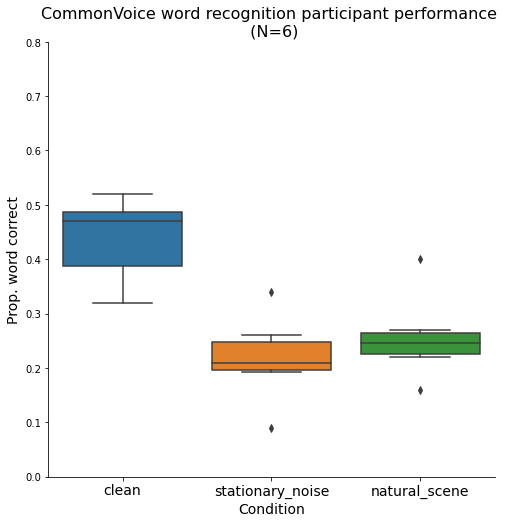

In [303]:
fontsize=14
n_participants = part_summary_df.jspsych_id.unique().shape[0]
fig, axs = plt.subplots(1, figsize=(8,8))

order = ['clean', 'stationary_noise', 'natural_scene']
p = sns.boxplot( data=part_summary_df, x="condition",
                   y="mean",  #error='sem',
                   order=order,
                  #capsize=0.1,
                   ax=axs)

sns.despine()
plt.ylim(0,0.8)
p.set_title(f"CommonVoice word recognition participant performance \n (N={n_participants})",
                 fontsize=fontsize + 2)
p.set_xlabel("Condition",fontsize=fontsize)
p.set_ylabel("Prop. word correct", fontsize=fontsize)

p.set_xticklabels(labels=order, rotation=0, size=fontsize)



([<matplotlib.axis.XTick at 0x2b9152775250>,
 [Text(0, 0, 'Model'), Text(1, 0, 'Participant')])

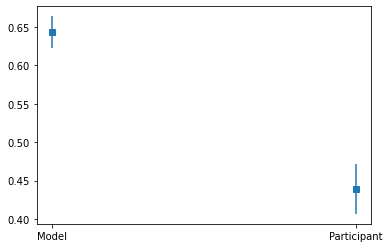

In [332]:
## Plot particiipant clean vs model clean

model_summary = model_results['ACC/test_acc_step'].agg(['mean', 'sem'])
human_summary = part_summary_df[part_summary_df.condition == 'clean']['mean'].agg(['mean', 'sem'])



plt.errorbar([0,1], [model_summary['mean'], human_summary['mean']], [model_summary['sem'], human_summary['sem']], marker='s', ls='none')
plt.xticks([0,1], ['Model', "Participant"])
